### Consulta 01


```sql

-- -------------------------------------------------------
-- CONSULTA 1 — EXTRACCIÓN
-- Todas las defunciones respiratorias (J00-J99)
-- con nombre de municipio, departamento y mes
-- -------------------------------------------------------
SELECT
    d.id                        AS id_defuncion,
    t.anio,
    t.mes,
    mu.nombre                   AS municipio_ocurrencia,
    dep.nombre                  AS departamento,
    cd.codigo_cie10,
    p.sexo,
    p.grupo_edad_2
FROM defuncion d
    JOIN causa_defuncion cd  ON cd.id_defuncion  = d.id
    JOIN persona         p   ON p.id             = d.id_persona
    JOIN tiempo          t   ON t.id             = d.id_tiempo
    JOIN municipio       mu  ON mu.id            = d.id_municipio_ocurrencia
    JOIN departamento    dep ON dep.id           = mu.id_departamento
WHERE cd.codigo_cie10 LIKE 'J%'   -- filtra solo enfermedades respiratorias
ORDER BY t.mes, dep.nombre;


```

**texto en negrita**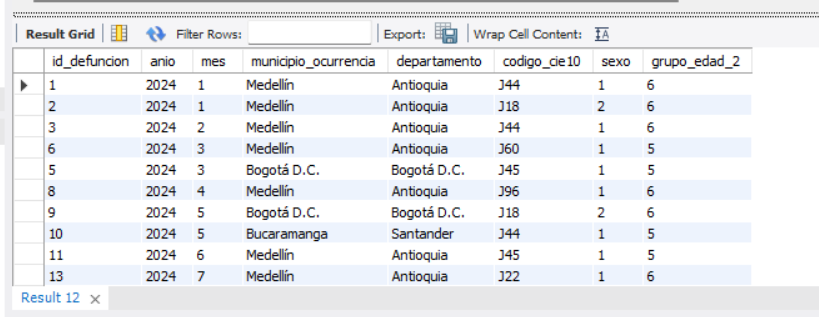

### Consulta 02


```sql

-- -------------------------------------------------------
-- CONSULTA 2 — TRANSFORMACIÓN
-- Conteo mensual de muertes respiratorias por departamento
-- con porcentaje sobre el total de defunciones del mes
-- -------------------------------------------------------
SELECT
    t.mes,
    dep.nombre                                              AS departamento,
    COUNT(*)                                                AS total_defunciones,
    SUM(CASE WHEN cd.codigo_cie10 LIKE 'J%' THEN 1 ELSE 0 END)
                                                            AS muertes_respiratorias,
    ROUND(
        SUM(CASE WHEN cd.codigo_cie10 LIKE 'J%' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*), 1
    )                                                       AS pct_respiratoria
FROM defuncion d
    JOIN causa_defuncion cd  ON cd.id_defuncion  = d.id
    JOIN tiempo          t   ON t.id             = d.id_tiempo
    JOIN municipio       mu  ON mu.id            = d.id_municipio_ocurrencia
    JOIN departamento    dep ON dep.id           = mu.id_departamento
GROUP BY t.mes, dep.nombre
ORDER BY t.mes, muertes_respiratorias DESC;



```

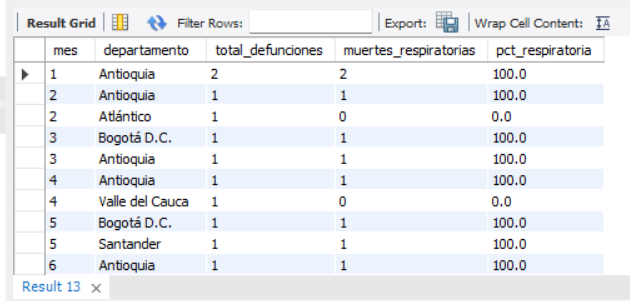

### Consulta 03


```sql
-- -------------------------------------------------------
-- CONSULTA 3 — REFINAMIENTO
-- Municipios con PM2.5 promedio anual > 15 µg/m³ (límite OMS)
-- que además tienen muertes respiratorias registradas
-- -------------------------------------------------------
SELECT
    mu.nombre                       AS municipio,
    dep.nombre                      AS departamento,
    ROUND(AVG(mca.pm25), 2)         AS pm25_promedio_anual,
    COUNT(DISTINCT d.id)            AS muertes_respiratorias
FROM municipio mu
    JOIN departamento           dep ON dep.id           = mu.id_departamento
    JOIN estacion_monitoreo     em  ON em.id_municipio  = mu.id
    JOIN medicion_calidad_aire  mca ON mca.id_estacion  = em.id
    JOIN defuncion              d   ON d.id_municipio_ocurrencia = mu.id
    JOIN causa_defuncion        cd  ON cd.id_defuncion  = d.id
WHERE cd.codigo_cie10 LIKE 'J%'
GROUP BY mu.id, mu.nombre, dep.nombre
HAVING AVG(mca.pm25) > 15            -- solo municipios sobre el límite OMS
ORDER BY pm25_promedio_anual DESC;

```

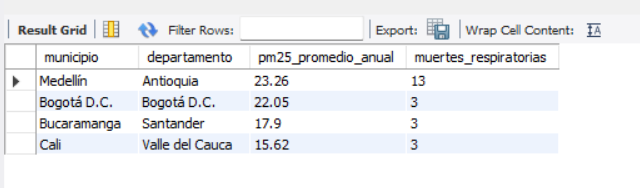

### Consulta 04


```sql

-- -------------------------------------------------------
-- CONSULTA 4 — SUBCONSULTA
-- Fallecidos por causa respiratoria cuyo municipio de ocurrencia
-- tiene un PM2.5 promedio superior al promedio nacional
-- -------------------------------------------------------
SELECT
    p.id                        AS id_persona,
    p.sexo,
    p.grupo_edad_2,
    p.ocupacion,
    mu.nombre                   AS municipio_ocurrencia,
    ROUND(sub.pm25_municipio, 2) AS pm25_promedio_municipio
FROM persona p
    JOIN defuncion       d   ON d.id_persona            = p.id
    JOIN causa_defuncion cd  ON cd.id_defuncion          = d.id
    JOIN municipio       mu  ON mu.id = d.id_municipio_ocurrencia
    JOIN (
        -- PM2.5 promedio por municipio (via sus estaciones)
        SELECT
            em.id_municipio,
            AVG(mca.pm25) AS pm25_municipio
        FROM estacion_monitoreo    em
            JOIN medicion_calidad_aire mca ON mca.id_estacion = em.id
        GROUP BY em.id_municipio
    ) sub ON sub.id_municipio = mu.id
WHERE cd.codigo_cie10 LIKE 'J%'
  AND sub.pm25_municipio > (
        -- promedio nacional de PM2.5 como referencia
        SELECT AVG(pm25) FROM medicion_calidad_aire
      )
ORDER BY sub.pm25_municipio DESC;

```

**texto en negrita**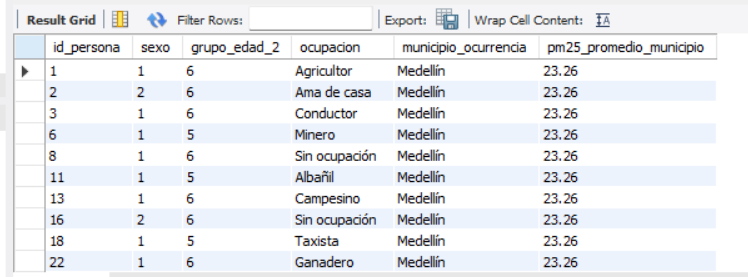

### Consulta 05


```sql

-- -------------------------------------------------------
-- CONSULTA 5 — CONTROL DE INTEGRIDAD
-- Detecta defunciones cuyo municipio de residencia
-- no existe en la tabla municipio (dato huérfano)
-- Útil antes de hacer JOINs con datos reales del DANE
-- -------------------------------------------------------
SELECT
    d.id                            AS id_defuncion,
    d.id_municipio_residencia       AS codigo_residencia_registrado,
    'Municipio de residencia no encontrado' AS alerta
FROM defuncion d
WHERE d.id_municipio_residencia IS NOT NULL
  AND d.id_municipio_residencia NOT IN (
        SELECT id FROM municipio
      )
UNION ALL
-- También verifica municipio de ocurrencia
SELECT
    d.id,
    d.id_municipio_ocurrencia,
    'Municipio de ocurrencia no encontrado'
FROM defuncion d
WHERE d.id_municipio_ocurrencia NOT IN (
        SELECT id FROM municipio
      );
```

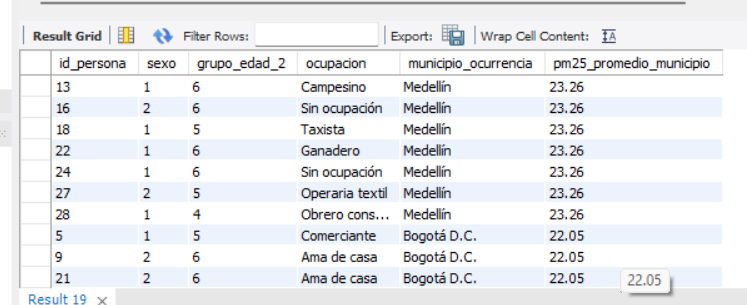